In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load RT_IOT2022 dataset
df = pd.read_csv("RT_IOT2022.csv")

# View first rows
df
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123112,2005,59247,63331,tcp,-,0.000006,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,2006,59247,64623,tcp,-,0.000007,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,2007,59247,64680,tcp,-,0.000006,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,2008,59247,65000,tcp,-,0.000006,1,1,0,0,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

,Unnamed: 0,id.orig_p,id.resp_p,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,...,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size
count,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000
mean,37035.089248,34639.258738,1014.305092,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,3.517620e+05,...,1.481354e+05,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514
std,30459.106367,19070.620354,5256.371994,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,3.708015e+05,...,1.613007e+06,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,6059.000000,17702.000000,21.000000,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,7.288927e+01,...,9.536740e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
50%,33100.000000,37221.000000,21.000000,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,2.467238e+05,...,4.053116e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
75%,63879.000000,50971.000000,21.000000,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,5.242880e+05,...,5.006790e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000
max,94658.000000,65535.000000,65389.000000,21728.335578,4345.000000,10112.000000,4345.000000,10105.000000,1.048576e+06,1.048576e+06,...,4.374931e+08,4.774862e+08,3.000000e+08,3.000000e+08,2.096777e+10,3.000000e+08,1.208029e+08,65535.000000,65535.000000,65535.000000


In [4]:
# Remove index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Check missing values
df.isnull().sum().head()

# Replace missing values with 0
df.fillna(0, inplace=True)


In [5]:
le = LabelEncoder()

df['proto'] = le.fit_transform(df['proto'])
df['service'] = le.fit_transform(df['service'])
df['Attack_type'] = le.fit_transform(df['Attack_type'])


In [6]:
# Compute correlation with target label
correlation = df.corr()['Attack_type'].abs().sort_values(ascending=False)

# Select top 20 features (excluding target itself)
selected_features = correlation[1:21].index.tolist()

print("Selected Features:")
selected_features


Selected Features:


['fwd_pkts_payload.min',
 'fwd_pkts_payload.avg',
 'flow_FIN_flag_count',
 'fwd_URG_flag_count',
 'fwd_init_window_size',
 'id.resp_p',
 'proto',
 'payload_bytes_per_second',
 'service',
 'bwd_pkts_payload.std',
 'bwd_pkts_per_sec',
 'flow_pkts_per_sec',
 'fwd_pkts_per_sec',
 'fwd_subflow_pkts',
 'flow_RST_flag_count',
 'bwd_pkts_payload.max',
 'id.orig_p',
 'bwd_pkts_payload.avg',
 'bwd_init_window_size',
 'flow_SYN_flag_count']

In [7]:
X = df[selected_features]
y = df['Attack_type']


In [8]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔑 Make y_test a pandas Series with index
y_test = pd.Series(y_test, index=X_test_df.index)


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf_model.predict(X_test)


In [12]:
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.998172514619883

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1550
           1       1.00      0.99      1.00       107
           2       1.00      1.00      1.00     18932
           3       1.00      1.00      1.00       829
           4       0.78      1.00      0.88         7
           5       0.83      0.83      0.83         6
           6       1.00      1.00      1.00       400
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       518
           9       1.00      1.00      1.00       402
          10       0.99      0.99      0.99      1622
          11       0.98      0.94      0.96        51

    accuracy                           1.00     24624
   macro avg       0.96      0.98      0.97     24624
weighted avg       1.00      1.00      1.00     24624



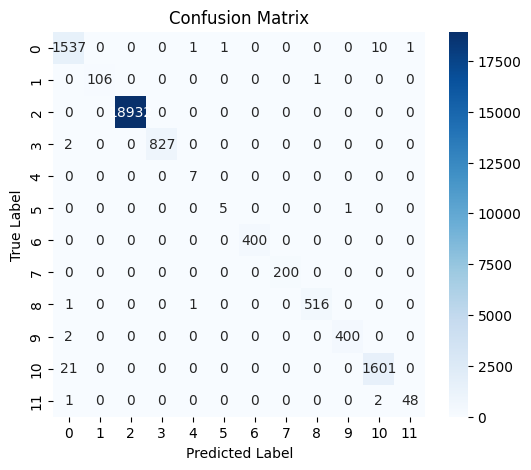

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [14]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df


,Feature,Importance
5,id.resp_p,0.191688
1,fwd_pkts_payload.avg,0.137207
0,fwd_pkts_payload.min,0.129299
15,bwd_pkts_payload.max,0.070760
8,service,0.066129
17,bwd_pkts_payload.avg,0.061509
7,payload_bytes_per_second,0.052145
19,flow_SYN_flag_count,0.035232
10,bwd_pkts_per_sec,0.032838
12,fwd_pkts_per_sec,0.028873


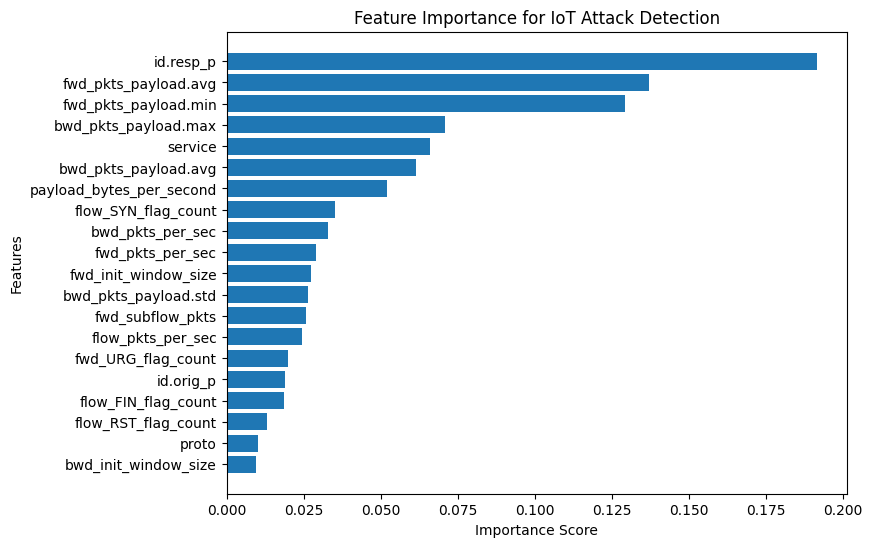

In [15]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for IoT Attack Detection")
plt.gca().invert_yaxis()
plt.show()


In [16]:
# ===============================
# MODEL 2: SUPPORT VECTOR MACHINE
# ===============================


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [18]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svm_model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
y_pred_svm = svm_model.predict(X_test)


In [20]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", svm_accuracy)

print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.994314489928525

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1550
           1       1.00      0.80      0.89       107
           2       1.00      1.00      1.00     18932
           3       1.00      1.00      1.00       829
           4       1.00      0.86      0.92         7
           5       0.62      0.83      0.71         6
           6       0.99      1.00      1.00       400
           7       0.99      1.00      1.00       200
           8       0.96      0.98      0.97       518
           9       1.00      1.00      1.00       402
          10       0.98      0.96      0.97      1622
          11       0.92      0.69      0.79        51

    accuracy                           0.99     24624
   macro avg       0.95      0.92      0.93     24624
weighted avg       0.99      0.99      0.99     24624



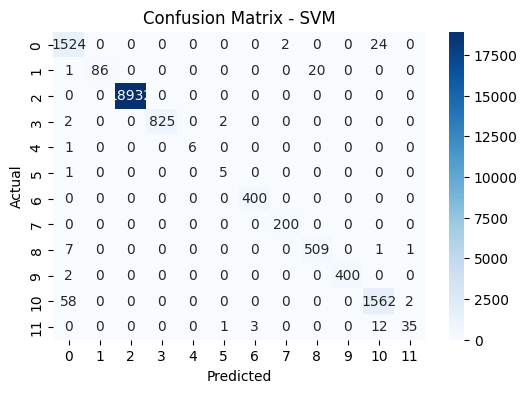

In [21]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [22]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Support Vector Machine"],
    "Accuracy": [rf_accuracy, svm_accuracy]
})

comparison_df


,Model,Accuracy
0,Random Forest,0.998173
1,Support Vector Machine,0.994314


In [23]:
import joblib

joblib.dump(rf_model, "iot_attack_detection_model.pkl")


['iot_attack_detection_model.pkl']

In [24]:
normal_label = y.value_counts().idxmax()
print("Normal traffic label:", normal_label)


Normal traffic label: 2


In [25]:
def get_user_flow_input_scenario():
    choice = int(input("Select Traffic Scenario (1–4): "))

    if choice == 1:
        # Guaranteed normal sample
        sample = X_test_df.loc[y_test == normal_label].sample(1)

    elif choice == 2:
        # Guaranteed attack sample
        sample = X_test_df.loc[y_test != normal_label].sample(1)

    elif choice == 3:
        sample = X_test_df.sample(1)

    elif choice == 4:
        sample = X.sample(1)

    else:
        print("Invalid choice, using random traffic.")
        sample = X.sample(1)

    sample_scaled = scaler.transform(sample)
    return sample_scaled


In [26]:
user_flow = get_user_flow_input_scenario()

prediction = rf_model.predict(user_flow)

if prediction[0] == 1:
    print("⚠️ Attack Detected in Network Flow")
else:
    print("✅ Normal Network Traffic")

# Probability (good for research)
prob = rf_model.predict_proba(user_flow)
print(f"Normal Probability: {prob[0][0]:.2f}")
print(f"Attack Probability: {prob[0][1]:.2f}")


ValueError: invalid literal for int() with base 10: ''

In [ ]:
prediction = rf_model.predict(user_flow)[0]

if prediction != normal_label:
    print("⚠️ Attack Detected in Network Flow")
    print("Predicted Attack Type:", prediction)
else:
    print("✅ Normal Network Traffic")


⚠️ Attack Detected in Network Flow
Predicted Attack Type: 8


In [ ]:
import joblib

joblib.dump(rf_model, "model.pkl")